# Compare Two-Stage Q-Learning Performance

This notebook compares the performance of Two-Stage Q-Learning vs standard Q-Learning approaches by fetching metrics from Azure ML experiments using MLflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import os

from azure.ai.ml import MLClient
from azure.identity import DefaultAzureCredential
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy import stats
# Enable inline plotting
%matplotlib inline

# Move to root folder for imports
os.chdir(Path.cwd().parent)
from src.azureml_utils import download_run_artifacts, download_runs_artifacts

# Load environment variables from .env file
load_dotenv()


True

In [3]:
# Connect to Azure ML Workspace using SDK v2 and setup MLflow
# The workspace will be loaded from config.json file if available, or you can specify parameters
try:
    # Using DefaultAzureCredential for authentication
    credential = DefaultAzureCredential()
    credential.get_token("https://management.azure.com/.default")
    # Create ML Client from config.json
    ml_client = MLClient.from_config(credential=credential)
    print(f"Connected to workspace: {ml_client.workspace_name}")
    print(f"Subscription: {ml_client.subscription_id}")
    print(f"Resource group: {ml_client.resource_group_name}")

except Exception as e:
    print(f"Error connecting to workspace: {e}")
    raise

# Set up MLflow tracking URI for Azure ML
tracking_uri = ml_client.workspaces.get(ml_client.workspace_name).mlflow_tracking_uri
mlflow.set_tracking_uri(tracking_uri)
print(f"✓ MLflow tracking URI set successfully to {mlflow.get_tracking_uri()}")

Found the config file in: ./config.json
Class DeploymentTemplateOperations: This is an experimental class, and may change at any time. Please see https://aka.ms/azuremlexperimental for more information.


Connected to workspace: mlw-research-pro-003
Subscription: 706e41e6-9c7a-47c4-b231-c6e8897cfb63
Resource group: rg-research-pro-003
✓ MLflow tracking URI set successfully to azureml://westeurope.api.azureml.ms/mlflow/v2.0/subscriptions/706e41e6-9c7a-47c4-b231-c6e8897cfb63/resourceGroups/rg-research-pro-003/providers/Microsoft.MachineLearningServices/workspaces/mlw-research-pro-003


In [4]:
experiment = mlflow.get_experiment_by_name("SIRS-Q-Learning")
runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], order_by=["start_time DESC"])
runs = runs[
    (runs["start_time"] >= "2026-04-14 22:12:00") & (runs["start_time"] <= "2026-04-15 06:00:00")
]  # Filter runs by start time

In [8]:
download_runs_artifacts(
    run_names=runs["run_id"].tolist(),
    output_dir="artifacts",
    storage_account_name=os.getenv("STORAGE_ACCOUNT_NAME"),
    storage_account_key=os.getenv("STORAGE_ACCOUNT_KEY"),
)

Runs: 100%|██████████| 40/40 [00:28<00:00,  1.42run/s]

Downloaded 40/40 runs to /Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts


{'icy_leather_wrh1j8ng1y': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/icy_leather_wrh1j8ng1y'),
 'silver_loquat_bqdskhvgny': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/silver_loquat_bqdskhvgny'),
 'plucky_bone_0tzy2qmlyq': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/plucky_bone_0tzy2qmlyq'),
 'red_pear_xn0sncxt77': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/red_pear_xn0sncxt77'),
 'lucid_pencil_088386tkbh': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/lucid_pencil_088386tkbh'),
 'salmon_apple_qhfdyn555p': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/salmon_apple_qhfdyn555p'),
 'sad_yacht_znjnrrd9yb': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/sad_yacht_znjnrrd9yb'),
 'ashy_kitten_v71wnm4w60': PosixPath('/Users/ccarballo/Projects/Research/epidemic-models-rl/artifacts/ashy

In [17]:
client = mlflow.tracking.MlflowClient()

In [18]:
def fetch_metric_history(client: mlflow.tracking.MlflowClient, run_id: str, key: str):
    try:
        history = client.get_metric_history(run_id, key)
        logging.info(f"Fetching {len(history)} entries for run_id {run_id} and key {key}")
        history = [metric.to_dictionary() for metric in history]
    except Exception as e:
        logging.exception(f"Error fetching metric history for run_id {run_id} and key {key}: {e}")
        history = []
    history = pd.DataFrame(history)
    return history

In [19]:
metric_name = "log_mean_relative_error"

def compute_mean_and_ci(df, confidence=0.95):
    """Compute mean and 95% CI per step across runs."""
    # TODO: Update formula if x=(x1,...,xN), then the interval is mean(x) - 1.96*quasisd(x)/sqrt(n) and mean(x) + 1.96*quasisd(x)/sqrt(n)
    grouped = df.groupby('step')['value']
    mean = grouped.mean()
    sem = grouped.sem()
    n = grouped.count()
    h = sem * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean.index, mean.values, (mean - h).values, (mean + h).values

def fetch_metrics_for_runs(runs_subset):
    """Fetch log MRE metric history for a subset of runs and return as DataFrame with learn_mode."""
    result = pd.DataFrame()
    for run in tqdm(runs_subset.itertuples(), total=len(runs_subset)):
        m = fetch_metric_history(client, run.run_id, metric_name)
        m["run_id"] = run.run_id
        result = pd.concat([result, m], ignore_index=True)
    result = result.merge(runs_subset[["run_id", "tags.learn_mode"]], on="run_id", how="left")
    return result

## Overall Log MRE — Size = 5

In [20]:
runs_5 = runs[runs["params.size"] == "5"]
metrics_5 = fetch_metrics_for_runs(runs_5)

complete_5 = metrics_5[metrics_5["tags.learn_mode"] == "complete"]
two_stage_5 = metrics_5[metrics_5["tags.learn_mode"] == "two_stages"]

print(f"Size=5 — Q-learning: {complete_5['run_id'].nunique()} runs | Smart Q-learning: {two_stage_5['run_id'].nunique()} runs")

100%|██████████| 30/30 [00:35<00:00,  1.20s/it]

Size=5 — Q-learning: 15 runs | Smart Q-learning: 15 runs


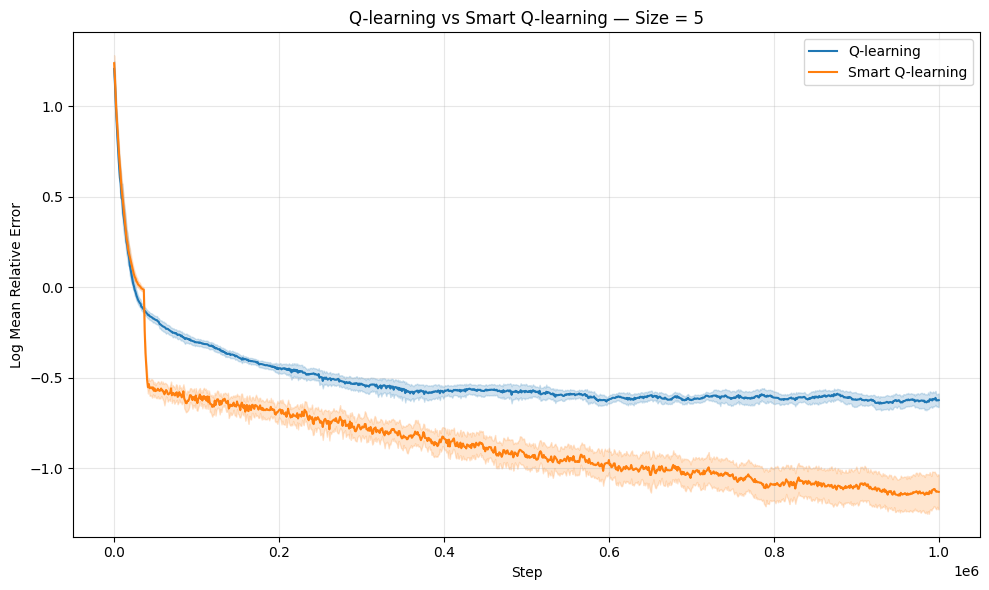

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_5.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_5)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_5.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_5)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 5")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
def get_local_artifacts_path(run_id: str) -> Path:
    """Get the local path to the artifacts of a given run."""
    PATH = Path("../data/azureml/ExperimentRun/ExperimentRun")
    # Paths PATH/dcid.<run_id>/
    # Assert folder exists or throw error if not
    local_path = PATH / f"dcid.{run_id}"
    if not local_path.exists():
        raise FileNotFoundError(f"Artifacts folder for run_id {run_id} does not exist.")
    return local_path

In [12]:
import re

def load_run_state_errors(run_id: str):
    """
    Load Q_true and all Q checkpoints from a downloaded artifact folder.
    Checkpoint folders follow the pattern chkpt_{episode}_{ep_step}_{global_step}/.
    Returns dict {global_step: log_mre_matrix (S+1, S+1)}, or None if not available.
    """
    try:
        artifacts_path = get_local_artifacts_path(run_id)
    except FileNotFoundError:
        return None

    q_true_files = list((artifacts_path / "Q_true").glob("*.npy"))
    if not q_true_files:
        return None
    Q_true = np.load(q_true_files[0])           # (S+1, S+1, A)
    safe_Q_true = np.where(Q_true != 0, Q_true, np.nan)

    results = {}
    for chkpt_dir in sorted(artifacts_path.glob("chkpt_*")):
        npy_files = list(chkpt_dir.glob("*.npy"))
        if not npy_files:
            continue
        # File name: Q_{episode}_{ep_step}_{global_step}.npy → capture last number
        match = re.search(r'_(\d+)\.npy$', npy_files[0].name)
        if not match:
            continue
        step = int(match.group(1))
        Q_ckpt = np.load(npy_files[0])          # (S+1, S+1, A)
        rel_err = np.abs(safe_Q_true - Q_ckpt) / np.abs(safe_Q_true)
        mre = np.nanmean(rel_err, axis=2)        # (S+1, S+1)
        results[step] = np.where(mre > 0, np.log10(mre), np.nan)

    return dict(sorted(results.items()))


# Load per-state errors for all runs in runs_5 that have downloaded artifacts
per_state_errors_5 = {}
for _, row in tqdm(runs_5.iterrows(), total=len(runs_5)):
    errors = load_run_state_errors(row["run_id"])
    if errors is not None:
        per_state_errors_5[row["run_id"]] = {
            "learn_mode": row["tags.learn_mode"],
            "errors": errors,
        }

n_complete   = sum(1 for v in per_state_errors_5.values() if v["learn_mode"] == "complete")
n_two_stages = sum(1 for v in per_state_errors_5.values() if v["learn_mode"] == "two_stages")
print(f"Loaded {len(per_state_errors_5)} runs with local artifacts "
      f"({n_complete} complete, {n_two_stages} two_stages)")

  0%|          | 0/30 [00:00<?, ?it/s]/var/folders/p2/znbcmbr934n_y9k59g_9_0_80000gn/T/ipykernel_45101/387532269.py:32: RuntimeWarning: Mean of empty slice
  mre = np.nanmean(rel_err, axis=2)        # (S+1, S+1)
100%|██████████| 30/30 [01:23<00:00,  2.77s/it]

Loaded 20 runs with local artifacts (10 complete, 10 two_stages)


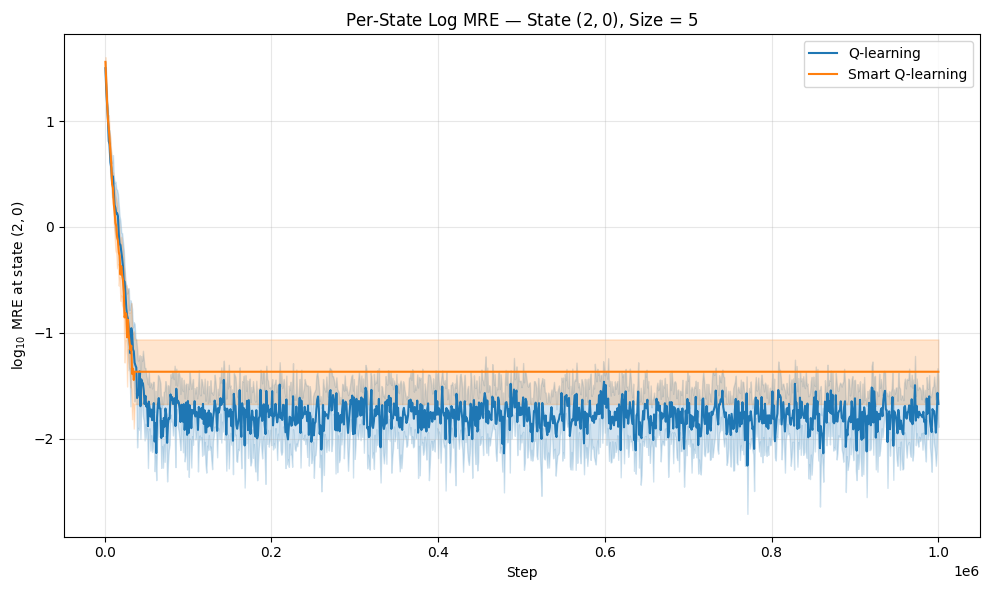

In [13]:
# Choose the state to plot
m_s, m_i = 2, 0

def compute_per_state_series(per_state_errors, learn_mode, m_s, m_i, confidence=0.95):
    """Compute mean and 95% CI across runs for a specific state (m_s, m_i)."""
    run_errors = {
        rid: v["errors"]
        for rid, v in per_state_errors.items()
        if v["learn_mode"] == learn_mode
    }
    if not run_errors:
        return None, None, None, None

    all_steps = sorted(set(s for e in run_errors.values() for s in e.keys()))
    values_by_step = {}
    for step in all_steps:
        vals = [e[step][m_s, m_i] for e in run_errors.values() if step in e]
        vals = [v for v in vals if not np.isnan(v)]
        if vals:
            values_by_step[step] = vals

    steps = sorted(values_by_step.keys())
    means = np.array([np.mean(values_by_step[s]) for s in steps])
    lo, hi = means.copy(), means.copy()
    for i, s in enumerate(steps):
        vals = values_by_step[s]
        n = len(vals)
        if n > 1:
            h = stats.sem(vals) * stats.t.ppf(0.975, n - 1)
            lo[i] = means[i] - h
            hi[i] = means[i] + h
    return steps, means, lo, hi


fig, ax = plt.subplots(figsize=(10, 6))

for learn_mode, label, color in [
    ("complete",   "Q-learning",       "tab:blue"),
    ("two_stages", "Smart Q-learning", "tab:orange"),
]:
    steps, means, lo, hi = compute_per_state_series(per_state_errors_5, learn_mode, m_s, m_i)
    if steps is not None:
        ax.plot(steps, means, label=label, color=color)
        ax.fill_between(steps, lo, hi, alpha=0.2, color=color)

ax.set_xlabel("Step")
ax.set_ylabel(f"$\\log_{{10}}$ MRE at state $({m_s}, {m_i})$")
ax.set_title(f"Per-State Log MRE — State $({m_s}, {m_i})$, Size = 5")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

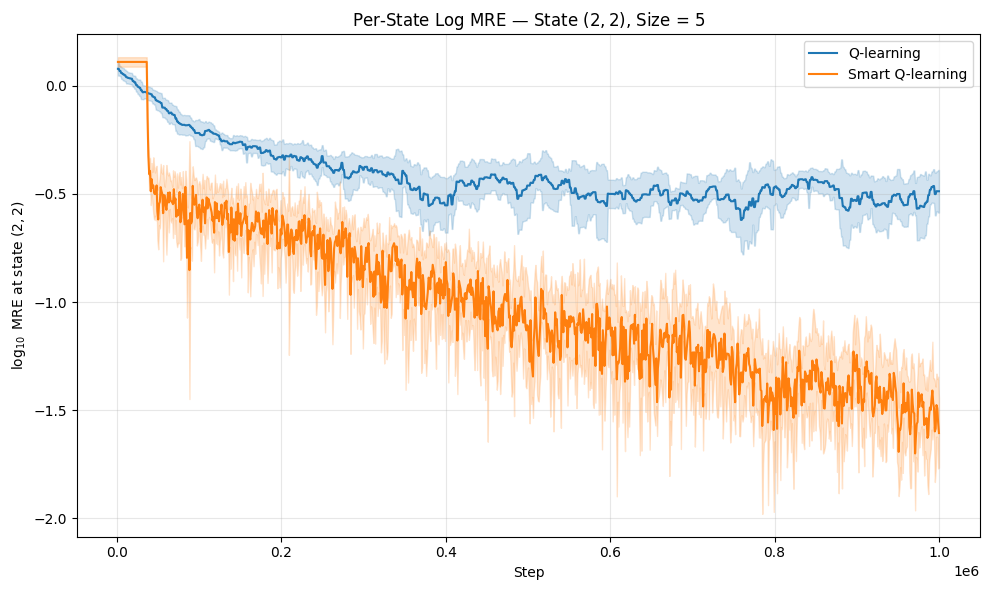

In [14]:
# Choose the state to plot
m_s, m_i = 2, 2

fig, ax = plt.subplots(figsize=(10, 6))

for learn_mode, label, color in [
    ("complete",   "Q-learning",       "tab:blue"),
    ("two_stages", "Smart Q-learning", "tab:orange"),
]:
    steps, means, lo, hi = compute_per_state_series(per_state_errors_5, learn_mode, m_s, m_i)
    if steps is not None:
        ax.plot(steps, means, label=label, color=color)
        ax.fill_between(steps, lo, hi, alpha=0.2, color=color)

ax.set_xlabel("Step")
ax.set_ylabel(f"$\\log_{{10}}$ MRE at state $({m_s}, {m_i})$")
ax.set_title(f"Per-State Log MRE — State $({m_s}, {m_i})$, Size = 5")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Overall Log MRE — Size = 5 - Resusceptible rate = 0, k=55000

In [34]:
runs_5_2 = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string='tags.run_group = "no_reinfection_5"', order_by=["start_time DESC"])
runs_5_2 = runs_5_2[runs_5_2["params.first_stage_steps"] == "55000"]
runs_5_2.shape

(20, 53)

In [35]:
metrics_5_2 = fetch_metrics_for_runs(runs_5_2)
complete_5_2 = metrics_5_2[metrics_5_2["tags.learn_mode"] == "complete"]
two_stage_5_2 = metrics_5_2[metrics_5_2["tags.learn_mode"] == "two_stages"]

100%|██████████| 20/20 [00:48<00:00,  2.43s/it]


Size=5 — Q-learning: 10 runs | Smart Q-learning: 10 runs


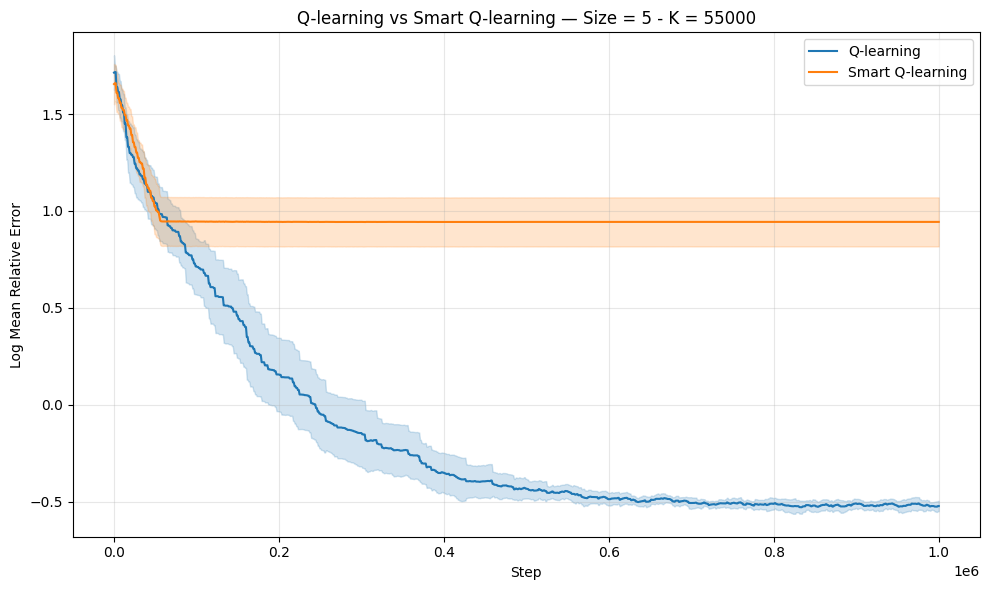

In [36]:
print(f"Size=5 — Q-learning: {complete_5_2['run_id'].nunique()} runs | Smart Q-learning: {two_stage_5_2['run_id'].nunique()} runs")
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_5_2.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_5_2)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_5_2.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_5_2)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 5 - K = 55000")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

100%|██████████| 10/10 [00:26<00:00,  2.66s/it]

Size=5 — Q-learning: 5 runs | Smart Q-learning: 5 runs


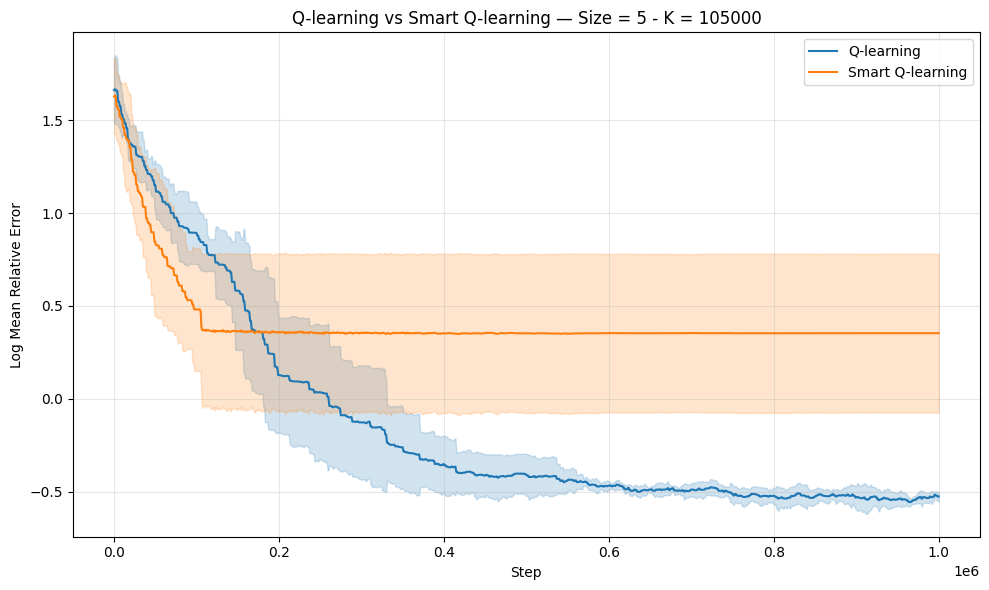

In [37]:
runs_5_3 = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string='tags.run_group = "no_reinfection_5"', order_by=["start_time DESC"])
runs_5_3 = runs_5_3[runs_5_3["params.first_stage_steps"] == "105000"]
runs_5_3.shape

metrics_5_3 = fetch_metrics_for_runs(runs_5_3)
complete_5_3 = metrics_5_3[metrics_5_3["tags.learn_mode"] == "complete"]
two_stage_5_3 = metrics_5_3[metrics_5_3["tags.learn_mode"] == "two_stages"]

print(f"Size=5 — Q-learning: {complete_5_3['run_id'].nunique()} runs | Smart Q-learning: {two_stage_5_3['run_id'].nunique()} runs")
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_5_3.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_5_3)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_5_3.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_5_3)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 5 - K = 105000")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Overall Log MRE — Size = 10

In [38]:
runs_10 = runs[runs["params.size"] == "10"]
metrics_10 = fetch_metrics_for_runs(runs_10)

complete_10 = metrics_10[metrics_10["tags.learn_mode"] == "complete"]
two_stage_10 = metrics_10[metrics_10["tags.learn_mode"] == "two_stages"]

print(f"Size=10 — Q-learning: {complete_10['run_id'].nunique()} runs | Smart Q-learning: {two_stage_10['run_id'].nunique()} runs")

  0%|          | 0/10 [00:00<?, ?it/s]ERROR:root:Error fetching metric history for run_id hungry_ship_stkmlgvmyd and key log_mean_relative_error: RESOURCE_DOES_NOT_EXIST: Response: {'Error': {'Code': 'UserError', 'Severity': None, 'Message': 'Run hungry_ship_stkmlgvmyd was not found', 'MessageFormat': None, 'MessageParameters': None, 'ReferenceCode': None, 'DetailsUri': None, 'Target': None, 'Details': [], 'InnerError': None, 'DebugInfo': None, 'AdditionalInfo': None}, 'Correlation': {'operation': '700e5499ad3e59c033a346e7a62b9060', 'request': '7875aa78c04f60ba'}, 'Environment': 'westeurope', 'Location': 'westeurope', 'Time': '2026-04-24T06:12:20.7145097+00:00', 'ComponentName': 'mlflow', 'statusCode': 404, 'error_code': 'RESOURCE_DOES_NOT_EXIST'}
Traceback (most recent call last):
  File "/var/folders/p2/znbcmbr934n_y9k59g_9_0_80000gn/T/ipykernel_45101/274206488.py", line 3, in fetch_metric_history
    history = client.get_metric_history(run_id, key)
              ^^^^^^^^^^^^^^^^^^^^

Size=10 — Q-learning: 0 runs | Smart Q-learning: 0 runs


/var/folders/p2/znbcmbr934n_y9k59g_9_0_80000gn/T/ipykernel_45101/763433079.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


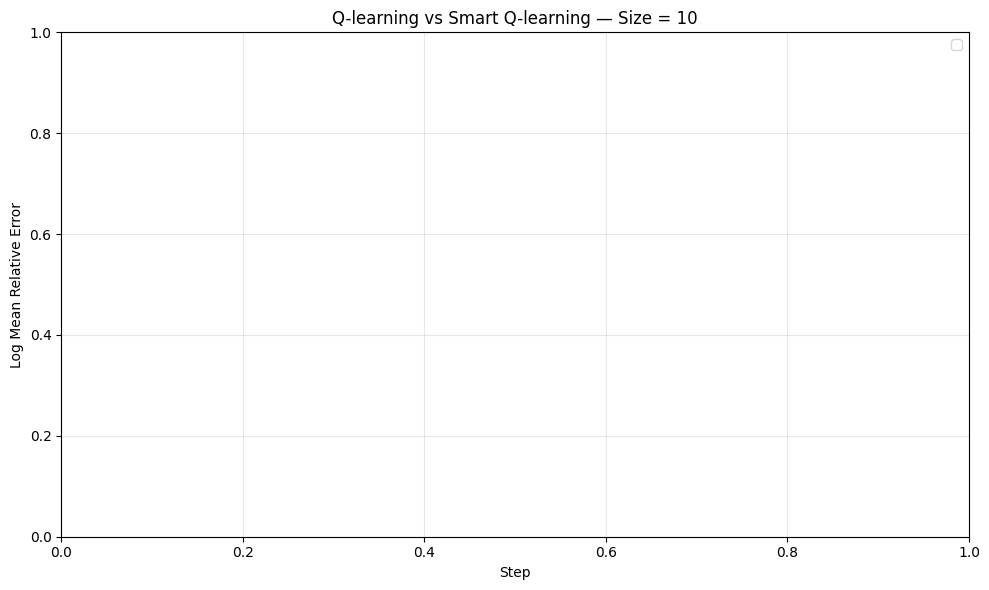

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_10.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_10)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_10.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_10)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 10")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Overall Log MRE — Size = 10 - K = 105000

In [46]:
runs_10_2 = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string='tags.run_group = "compare_size_10"', order_by=["start_time DESC"])
runs_10_2 = runs_10_2[runs_10_2["params.first_stage_steps"] == "105000"]
runs_10_2 = runs_10_2[runs_10_2["params.size"] == "10"]
runs_10_2.shape

(10, 53)

In [47]:
metrics_10_2 = fetch_metrics_for_runs(runs_10_2)
complete_10_2 = metrics_10_2[metrics_10_2["tags.learn_mode"] == "complete"]
two_stage_10_2 = metrics_10_2[metrics_10_2["tags.learn_mode"] == "two_stages"]

100%|██████████| 10/10 [00:29<00:00,  2.98s/it]


Size=10 — Q-learning: 5 runs | Smart Q-learning: 5 runs


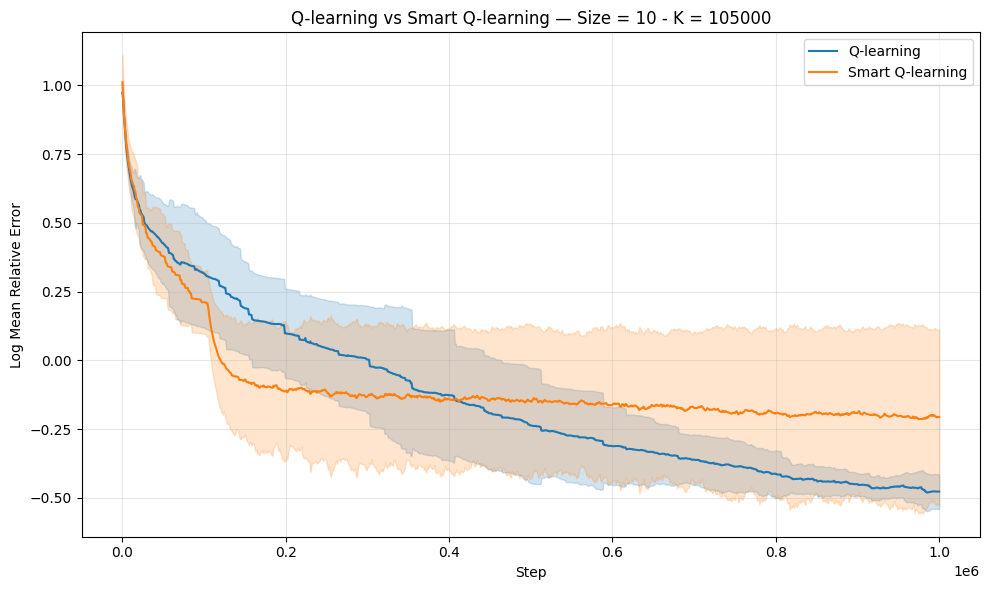

In [48]:
print(f"Size=10 — Q-learning: {complete_10_2['run_id'].nunique()} runs | Smart Q-learning: {two_stage_10_2['run_id'].nunique()} runs")
fig, ax = plt.subplots(figsize=(10, 6))

if not complete_10_2.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_10_2)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_10_2.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_10_2)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — Size = 10 - K = 105000")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment with no resusceptible rate and using improved first-phase

In [11]:
runs_56 = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string='tags.run_group = "compare_no_reinfection_short_5"', order_by=["start_time DESC"])
runs_56.shape

(10, 56)

In [21]:
metrics_56 = fetch_metrics_for_runs(runs_56)

complete_56 = metrics_56[metrics_56["tags.learn_mode"] == "complete"]
two_stage_56 = metrics_56[metrics_56["tags.learn_mode"] == "two_stages"]

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:10<00:00,  1.04s/it]


Q-learning: 5 runs | Smart Q-learning: 5 runs


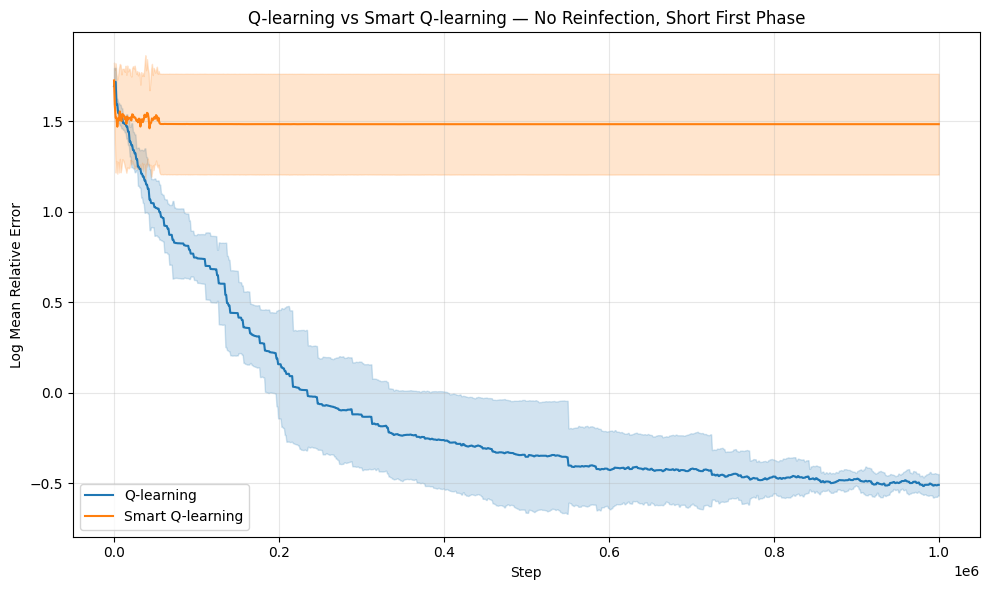

In [22]:
print(f"Q-learning: {complete_56['run_id'].nunique()} runs | Smart Q-learning: {two_stage_56['run_id'].nunique()} runs")

fig, ax = plt.subplots(figsize=(10, 6))

if not complete_56.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_56)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_56.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_56)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — No Reinfection, Short First Phase")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
runs_33 = mlflow.search_runs(experiment_ids=[experiment.experiment_id], filter_string='tags.run_group = "compare_5"', order_by=["start_time DESC"])
runs_33.shape

metrics_33 = fetch_metrics_for_runs(runs_33)

complete_33 = metrics_33[metrics_33["tags.learn_mode"] == "complete"]
two_stage_33 = metrics_33[metrics_33["tags.learn_mode"] == "two_stages"]

100%|██████████| 10/10 [00:10<00:00,  1.04s/it]


Q-learning: 5 runs | Smart Q-learning: 5 runs


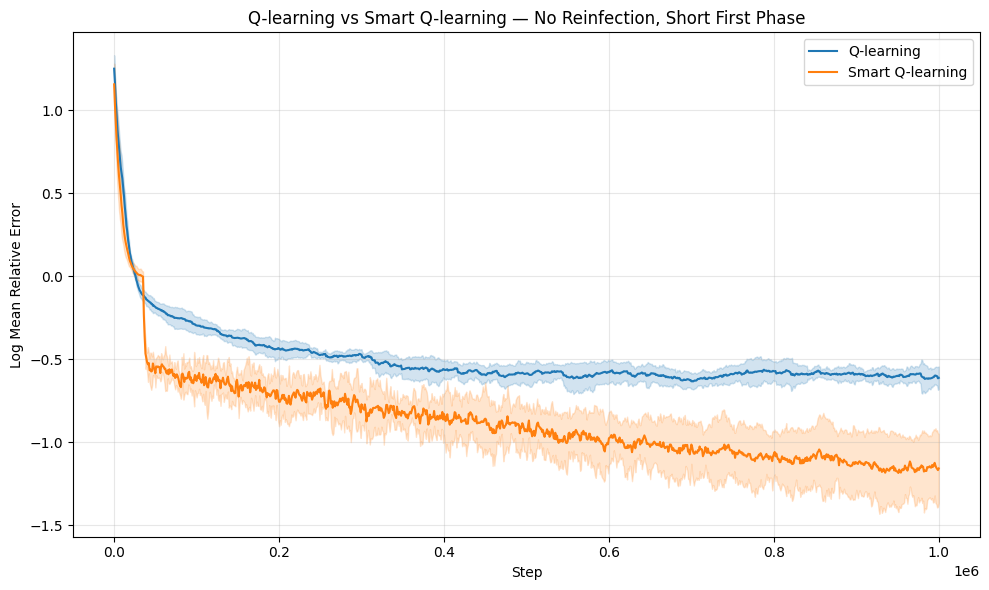

In [24]:
print(f"Q-learning: {complete_33['run_id'].nunique()} runs | Smart Q-learning: {two_stage_33['run_id'].nunique()} runs")

fig, ax = plt.subplots(figsize=(10, 6))

if not complete_33.empty:
    steps_c, mean_c, lo_c, hi_c = compute_mean_and_ci(complete_33)
    ax.plot(steps_c, mean_c, label="Q-learning", color="tab:blue")
    ax.fill_between(steps_c, lo_c, hi_c, alpha=0.2, color="tab:blue")

if not two_stage_33.empty:
    steps_t, mean_t, lo_t, hi_t = compute_mean_and_ci(two_stage_33)
    ax.plot(steps_t, mean_t, label="Smart Q-learning", color="tab:orange")
    ax.fill_between(steps_t, lo_t, hi_t, alpha=0.2, color="tab:orange")

ax.set_xlabel("Step")
ax.set_ylabel("Log Mean Relative Error")
ax.set_title("Q-learning vs Smart Q-learning — No Reinfection, Short First Phase")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()